In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import hdbscan
import pacmap

from sklearn.preprocessing import MinMaxScaler
from scipy import stats

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
data = pd.read_excel('data/Pyrolysis_Data_4-15_Reduced.xlsx')

data.describe()

,Unnamed: 0,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
count,5815,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,...,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000,5815.000000
mean,2016-03-04 04:55:41.197123072,52144.242783,8020.089319,8484.313033,8763.022310,8700.905784,8913.347552,9107.484703,4423.968811,4498.331371,...,610.578828,618.413633,837.924409,837.986843,837.982059,837.988895,837.994263,837.973035,1039.254438,837.978388
min,2016-02-08 00:01:00,46856.338783,6758.341598,7502.572819,7756.021172,7636.394988,7263.718622,8294.338037,4340.675387,4378.762040,...,578.036169,593.247029,813.677644,813.655302,814.223515,813.335615,813.019405,812.818273,1003.175885,815.114174
25%,2016-02-20 14:27:30.004000,52033.568875,7874.100027,8361.082076,8701.887638,8485.859468,8768.986543,9054.652077,4396.991155,4493.667731,...,605.507556,616.132093,837.077828,837.063358,837.304227,837.028101,837.078821,837.142470,1031.783117,837.719943
50%,2016-03-04 04:49:00.007000064,52121.043123,7995.312979,8457.509488,8743.298453,8751.611230,8992.690513,9106.313373,4402.973596,4499.921253,...,611.845846,618.620439,837.969176,837.955936,837.993078,838.015884,838.060860,838.028199,1041.054499,838.009360
75%,2016-03-16 19:23:30.011000064,52227.729108,8189.934132,8593.463246,8782.845713,8828.188249,9124.855149,9187.984863,4420.461732,4505.838867,...,614.807537,620.874401,838.837397,838.850038,838.689006,839.026625,839.010758,838.899341,1048.160797,838.283806
max,2016-03-29 09:45:00.014000,53985.986703,8839.589150,9299.937677,9408.602725,9161.440386,9347.902143,9748.060142,4539.796524,4547.570254,...,631.350065,625.383420,848.344403,850.031615,847.075560,847.412148,852.118269,851.352835,1057.304593,844.905772
std,NaN,328.852391,221.345774,169.842371,145.333741,183.394193,319.595858,161.098147,43.267051,15.975587,...,6.111844,3.201523,1.952291,1.855611,1.597137,1.865743,2.010982,1.790704,10.363310,1.231560


In [4]:
def plot_data(data):

    fig = plt.figure(figsize=(10, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    for col in data.iloc[:, 1:].columns:

        axs0.plot(np.asarray(data.iloc[:, 0]), np.asarray(data[col]))


    axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', rotation=45)

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)


    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

In [5]:
def plot_clusters(data, basis_data = None, dr_model = None):
    scaler = MinMaxScaler(feature_range=(-1, 1))
        
    scaled_data = pd.DataFrame(scaler.fit_transform(data.iloc[:, 1:]))


    scaled_data.head()

    # Project data in 2D
    if dr_model is None:
        dr_model = pacmap.PaCMAP(
            n_neighbors=10,
            MN_ratio=5,
            FP_ratio=20,
            # distance=euclidean,
            lr=1.0,
            apply_pca=True,
            verbose=False,
            intermediate=False,
            save_tree=True
            )

        reduced_data = dr_model.fit_transform(scaled_data.values, )
    
    else:
        reduced_data = dr_model.transform(scaled_data.values, basis = basis_data.iloc[:, 1:].values)


    # get clusters

    cl_model = hdbscan.HDBSCAN(
        min_samples=int(np.floor(scaled_data.shape[0] / 50)))
    labels = cl_model.fit_predict(reduced_data)

    clustered_df = pd.DataFrame(
        data={
            'd0': reduced_data[:, 0],
            'd1': reduced_data[:, 1],
            # 'd2': reduced_data[:, 2],
            'label': labels
        })

    clustered_df['target'] = data.iloc[:, -1]

    fig1 = plt.figure(figsize=(5, 5))

    clustered_df_denoised = clustered_df.loc[clustered_df.label != -1]

    axs1 = fig1.add_subplot(111)  #projection='3d')
    print('Preparing plot...')

    colors = clustered_df_denoised['label']
    cmap='Set3'

    axs1.scatter(
        clustered_df_denoised['d0'],
        clustered_df_denoised['d1'],
        #this_cluster['d2'],
        s=10,
        cmap=cmap,
        c=colors,#clustered_df_denoised['label'],  #data.iloc[:, 1]
        # marker='o',
        edgecolors='k',
        # alpha=0.9,
        linewidths=0.1,
        # label=label
        )

    noise_df = clustered_df.loc[clustered_df.label == -1]

    axs1.scatter(
                noise_df['d0'],
                noise_df['d1'],
                #this_cluster['d2'],
                s=7,
                cmap=cmap,
                c='k',  #data.iloc[:, 1]
                # marker='o',
                edgecolors='k',
                alpha=0.4,
                linewidths=0.1,
    )

    axs1.set_xlabel(r'$ \rm PaCAMP\ 0$', labelpad = 10, fontsize='x-large')
    axs1.set_ylabel(r'$ \rm PaCAMP\ 1$', labelpad = 10, fontsize='x-large')

    axs1.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large')

    axs1.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs1.spines[ax].set_linewidth(1)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return dr_model
 

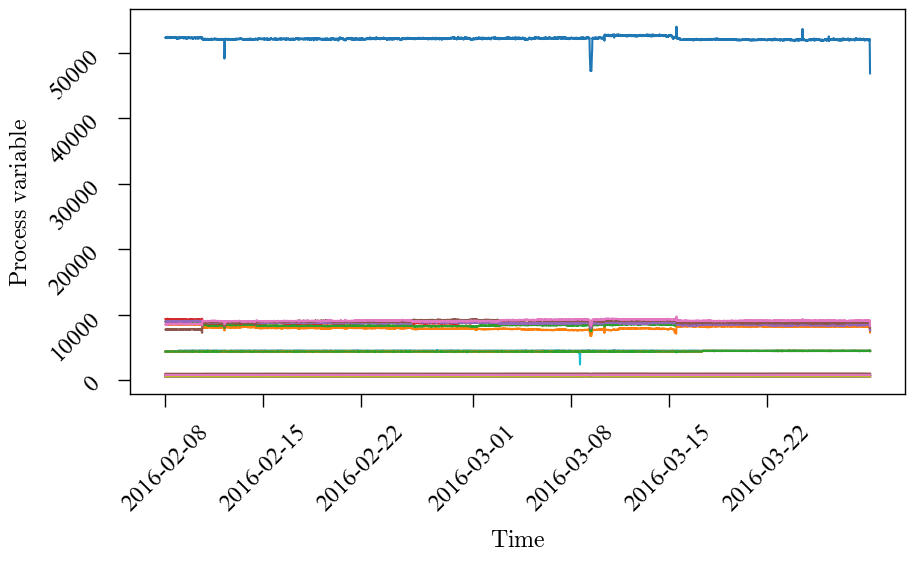

In [7]:
plot_data(data)

Preparing plot...


/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/q5/6txyk4317txfn_vkvk6sbl9m0000gn/T/ipykernel_35128/3776680687.py:71: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs1.scatter(


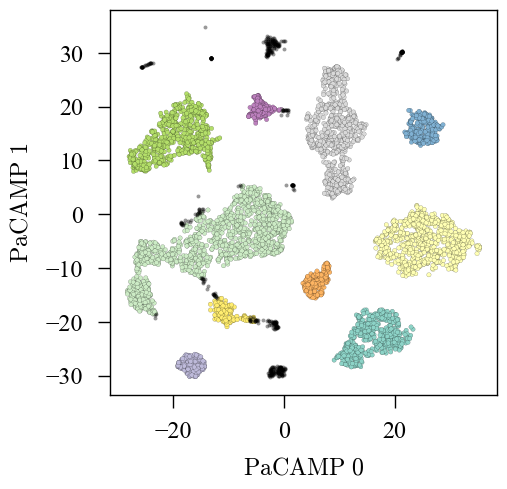

In [9]:
dr_model = plot_clusters(data)

In [10]:
filtered_data = data.copy()

for i, col in enumerate(filtered_data.columns):
    if i == 0:
        continue

    filtered_data[col] = filtered_data[col][(np.abs(stats.zscore(filtered_data[col])) < 3)]

filtered_data.describe()

,Unnamed: 0,11FI05101PV,11FC05031PV1,11FC05032PV1,11FC05033PV1,11FC05034PV1,11FC05035PV1,11FC05036PV1,11FC05041PV1,11FC05042PV1,...,11TI05005PV,11TI05006PV,11TDC05011PV1,11TDC05012PV1,11TDC05013PV1,11TDC05014PV1,11TDC05015PV1,11PI05016PV,11TI05044PV,11TC05000PV1
count,5815,5783.000000,5773.000000,5749.000000,5491.000000,5803.000000,5512.000000,5531.000000,5815.000000,5712.000000,...,5798.000000,5801.000000,5750.000000,5760.000000,5760.000000,5768.000000,5767.000000,5768.000000,5805.000000,5759.000000
mean,2016-03-04 04:55:41.197123072,52161.920539,8025.473264,8482.959242,8736.151008,8702.298668,8975.730768,9134.393037,4423.968811,4500.067510,...,610.627616,618.464071,837.990378,838.012431,838.007258,838.016939,838.032971,838.008242,1039.312231,838.008556
min,2016-02-08 00:01:00,51224.398618,7363.155132,8000.091382,8327.091064,8178.879619,8009.251351,8624.384049,4340.675387,4459.154000,...,594.680354,609.113756,832.278490,832.549125,833.433820,832.395520,831.983982,832.613209,1009.891070,834.621018
25%,2016-02-20 14:27:30.004000,52034.970868,7876.851961,8361.386863,8699.396754,8486.620605,8783.920000,9061.391481,4396.991155,4494.101910,...,605.539871,616.153628,837.094762,837.068622,837.310213,837.034625,837.090062,837.147399,1031.810766,837.721794
50%,2016-03-04 04:49:00.007000064,52121.753599,7997.232421,8457.001483,8739.771014,8751.938141,9005.211508,9111.732031,4402.973596,4500.144194,...,611.869398,618.630017,837.974266,837.953903,837.990963,838.014905,838.063536,838.028090,1041.078312,838.008946
75%,2016-03-16 19:23:30.011000064,52228.222187,8190.200397,8592.395658,8776.071234,8828.379405,9130.631798,9198.700033,4420.461732,4505.963065,...,614.807798,620.881219,838.830266,838.836162,838.681194,839.016220,839.006170,838.892252,1048.168670,838.279590
max,2016-03-29 09:45:00.014000,52875.515807,8614.410260,8993.734666,9008.437482,9161.440386,9347.902143,9430.591542,4539.796524,4538.761548,...,627.425146,625.383420,843.749166,843.547400,842.771015,843.534939,843.986951,843.340634,1057.304593,841.520866
std,NaN,187.033213,206.852067,155.859540,61.673778,180.912199,181.206570,109.787022,43.267051,9.182237,...,5.947637,3.027623,1.451912,1.422194,1.107359,1.484214,1.593807,1.348987,10.278028,0.464541


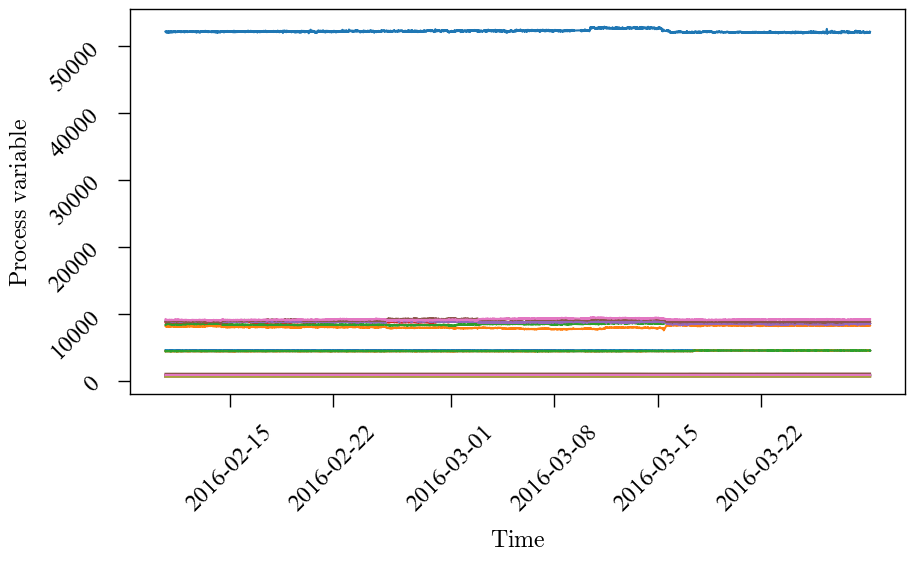

In [12]:
plot_data(filtered_data.dropna())

Preparing plot...


/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/q5/6txyk4317txfn_vkvk6sbl9m0000gn/T/ipykernel_35128/3776680687.py:71: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  axs1.scatter(


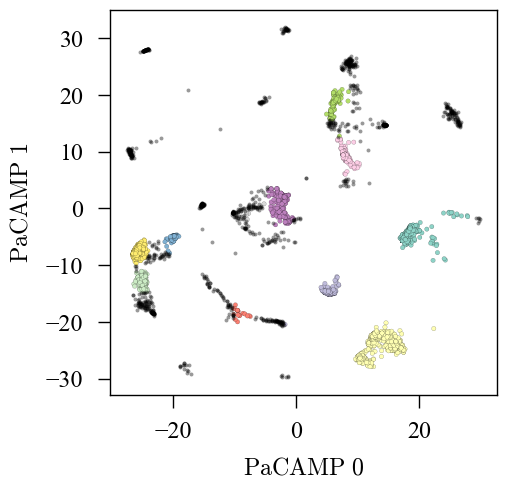

In [13]:
dr_model = plot_clusters(data = filtered_data.dropna(), basis_data=data, dr_model=dr_model)

In [14]:
def plot_window(data, lb, ub):

    fig = plt.figure(figsize=(5, 5))
    axs0 = fig.add_subplot(1, 1, 1)

    for col in data.iloc[:, 1:].columns:

        axs0.plot(np.asarray(data.iloc[lb:ub, 0]), np.asarray(data[col])[lb:ub])


    axs0.set_xlabel(r'$ \rm Time$', labelpad = 10, fontsize='x-large')
    axs0.set_ylabel(r'$ \rm Process\ variable$', labelpad = 10, fontsize='x-large')

    axs0.tick_params(direction='out',
                        pad=10,
                        length=9,
                        width=1,
                        labelsize='x-large', rotation=45)

    axs0.tick_params(which='minor',
                        direction='out',
                        pad=10,
                        length=5,
                        width=1,
                        labelsize='x-large')

    for ax in ['top', 'bottom', 'left', 'right']:
        axs0.spines[ax].set_linewidth(1)

    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=12
    plt.rcParams['axes.linewidth'] = 1 

    plt.show()

    return None

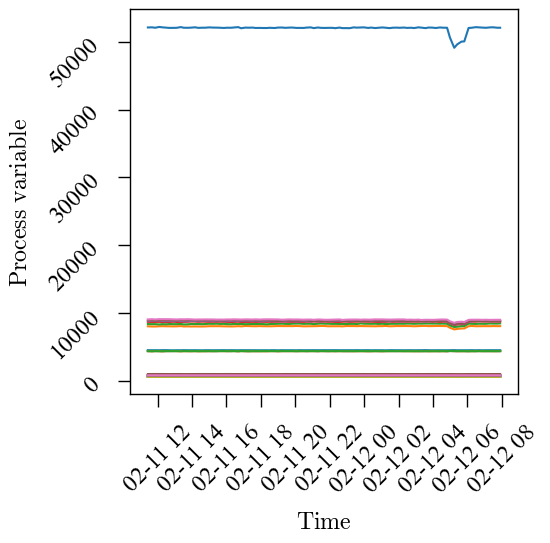

In [15]:
plot_window(data, 400, 500)

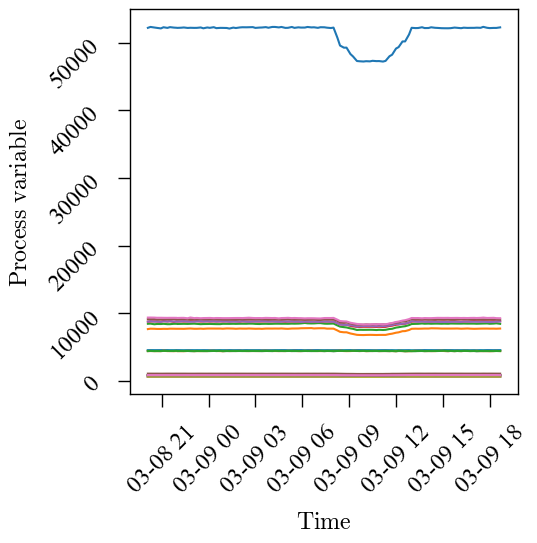

In [16]:
plot_window(data, 3440, 3550)

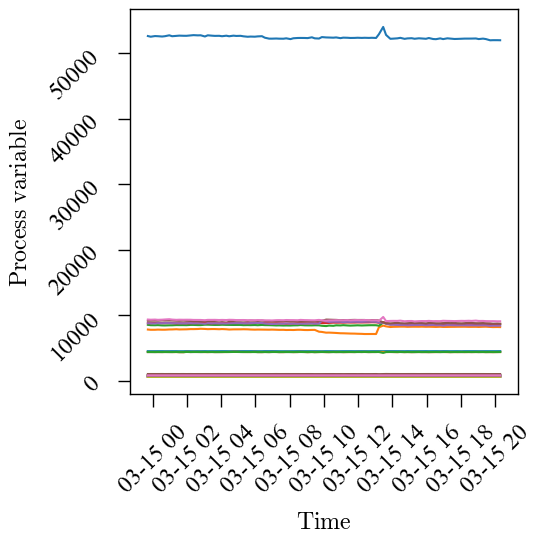

In [17]:
plot_window(data, 4150, 4250)